In [1]:
import os
from io import BytesIO

import numpy as np
import pandas as pd
from scipy.stats import genhyperbolic
from pai.session import get_default_session

E:\anaconda3\envs\latitude_env_v1\Lib\site-packages\pai\common\oss_utils.py:29: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
pai_session = get_default_session()
oss_bucket = pai_session.oss_bucket

parquet_path = r"E:\Latitude_Analytics_v2\00_draft_collection_02\research_outputs\testing_10\rb_main_minute.parquet"
oss_object_key = "testing_10/input/rb_main_minute.parquet"

oss_bucket.put_object_from_file(oss_object_key, parquet_path)

main_minute_df = pd.read_parquet(
    BytesIO(oss_bucket.get_object(oss_object_key).read())
)

main_minute_df

,contract_code,exchange_code,underlying_code,trading_date,session_number,bar_at,open,high,low,close,...,continuity_segment,is_roll,selection_reason,main_contract_signal_volume,incumbent_signal_volume,challenger_contract_code,challenger_signal_volume,roll_trigger_ratio,backward_adjusted_log_close,forward_adjusted_log_close
0,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:01:00+08:00,2550.0,2556.0,2546.0,2554.0,...,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.845416,7.378407
1,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:02:00+08:00,2555.0,2560.0,2555.0,2557.0,...,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.84659,7.379581
2,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:03:00+08:00,2556.0,2558.0,2555.0,2557.0,...,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.84659,7.379581
3,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:04:00+08:00,2556.0,2562.0,2556.0,2559.0,...,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.847372,7.380363
4,RB1505.XSGE,XSGE,RB,2015-01-05,2,2015-01-05 09:05:00+08:00,2559.0,2559.0,2556.0,2556.0,...,1,False,incumbent_retained,4148900.0,4148900.0,RB1510.XSGE,288258.0,1.1,7.846199,7.37919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998710,RB2610.XSGE,XSGE,RB,2026-09-01,4,2026-09-01 14:56:00+08:00,3122.0,3124.0,3122.0,3123.0,...,1,False,incumbent_retained,777186.0,777186.0,RB2701.XSGE,684968.0,1.1,8.513558,8.046549
998711,RB2610.XSGE,XSGE,RB,2026-09-01,4,2026-09-01 14:57:00+08:00,3123.0,3123.0,3122.0,3122.0,...,1,False,incumbent_retained,777186.0,777186.0,RB2701.XSGE,684968.0,1.1,8.513238,8.046229
998712,RB2610.XSGE,XSGE,RB,2026-09-01,4,2026-09-01 14:58:00+08:00,3122.0,3124.0,3122.0,3122.0,...,1,False,incumbent_retained,777186.0,777186.0,RB2701.XSGE,684968.0,1.1,8.513238,8.046229
998713,RB2610.XSGE,XSGE,RB,2026-09-01,4,2026-09-01 14:59:00+08:00,3122.0,3124.0,3122.0,3123.0,...,1,False,incumbent_retained,777186.0,777186.0,RB2701.XSGE,684968.0,1.1,8.513558,8.046549


In [3]:
dlc_code = """
import os
import pandas as pd
from scipy.stats import genhyperbolic

main_minute_df = pd.read_parquet(
    os.path.join(os.environ["PAI_INPUT_MINUTE"], "rb_main_minute.parquet"),
    columns=["bar_at", "trading_date", "backward_adjusted_log_close"],
).sort_values("bar_at")

main_minute_df["log_return"] = (
    main_minute_df["backward_adjusted_log_close"].diff()
)

minute_returns_df = main_minute_df[
    ["bar_at", "trading_date", "log_return"]
].iloc[1:].copy()
"""

In [4]:
dlc_code += """
minute_returns_df["trading_date"] = pd.to_datetime(
    minute_returns_df["trading_date"]
)

first_month = minute_returns_df["trading_date"].min().to_period("M")
last_month = minute_returns_df["trading_date"].max().to_period("M")

rolling_windows = [
    ((end_month - 12).to_timestamp(), end_month.to_timestamp())
    for end_month in pd.period_range(first_month + 12, last_month, freq="M")
]
"""

In [5]:
dlc_code += """
node_rank = int(os.environ["RANK"])
node_count = int(os.environ["WORLD_SIZE"])
node_windows = rolling_windows[node_rank::node_count]

gh_fit_rows = []

for window_index, (window_start, window_end) in enumerate(node_windows, 1):
    window_returns = minute_returns_df.loc[
        (minute_returns_df["trading_date"] >= window_start)
        & (minute_returns_df["trading_date"] < window_end),
        "log_return",
    ].to_numpy(dtype=float)

    print(
        f"node={node_rank} window={window_index}/{len(node_windows)} "
        f"start={window_start.date()} end={window_end.date()} "
        f"samples={len(window_returns)}",
        flush=True,
    )

    p, a, b, loc, scale = genhyperbolic.fit(window_returns, method="MLE")

    gh_fit_rows.append({
        "window_start": window_start,
        "window_end": window_end,
        "sample_count": len(window_returns),
        "p": p, "a": a, "b": b, "loc": loc, "scale": scale,
    })

gh_fit_df = pd.DataFrame(gh_fit_rows)
"""

In [6]:
dlc_code += """
gh_output_dir = os.environ["PAI_OUTPUT_MODEL"]
os.makedirs(gh_output_dir, exist_ok=True)

gh_output_path = os.path.join(
    gh_output_dir,
    f"gh_fit_node_{node_rank}.parquet",
)
gh_fit_df.to_parquet(gh_output_path, index=False)

print(f"node={node_rank} saved={gh_output_path}", flush=True)
"""

In [7]:
oss_code_prefix = "testing_10/code/"

oss_bucket.put_object(
    oss_code_prefix + "gh_fit.py",
    dlc_code.encode("utf-8"),
)
oss_bucket.put_object(
    oss_code_prefix + "requirements.txt",
    b"pandas\nscipy\npyarrow\n",
)

dlc_source_uri = f"oss://{oss_bucket.bucket_name}/{oss_code_prefix}"
dlc_source_uri

'oss://oss-pai-q00s96z5hnrhywm9ns-cn-shenzhen/testing_10/code/'

In [11]:
from pai.session import setup_default_session
from pai.estimator import Estimator
from pai.image import retrieve

pai_session = setup_default_session(network="PUBLIC")
oss_bucket = pai_session.oss_bucket

dlc_image = retrieve(
    framework_name="PyTorch",
    framework_version="latest",
    accelerator_type="CPU",
    session=pai_session,
)

dlc_estimator = Estimator(
    image_uri=dlc_image.image_uri,
    command="python gh_fit.py",
    source_dir=dlc_source_uri,
    job_type="PyTorchJob",
    instance_type="ecs.c6.large",
    instance_count=4,
    base_job_name="rb-gh-rolling",
    output_path=f"oss://{oss_bucket.bucket_name}/testing_10/output/",
    session=pai_session,
)

dlc_image.image_uri

'dsw-registry-vpc.cn-shenzhen.cr.aliyuncs.com/pai/pytorch-training:1.12-cpu-py39-ubuntu20.04'

In [14]:
from pai.job import TrainingJob

dlc_job_id = "trainjso4qyp6r1r"

dlc_job = TrainingJob.get(dlc_job_id, session=pai_session)

print(f"任务状态：{dlc_job.status}")
print(dlc_job.console_uri)

View the job detail by accessing the console URI: https://pai.console.aliyun.com/?regionId=cn-shenzhen&workspaceId=351454#/training/jobs/trainjso4qyp6r1r
https://pai.console.aliyun.com/?regionId=cn-shenzhen&workspaceId=351454#/training/jobs/trainjso4qyp6r1r


In [15]:
from pai.common.oss_utils import OssUriObj

gh_output_uri = dlc_job.output_path("model")
gh_output_prefix = OssUriObj(gh_output_uri).object_key.rstrip("/") + "/"

gh_fit_df = pd.concat([
    pd.read_parquet(BytesIO(oss_bucket.get_object(
        f"{gh_output_prefix}gh_fit_node_{node_rank}.parquet"
    ).read()))
    for node_rank in range(4)
], ignore_index=True).sort_values("window_start").reset_index(drop=True)

gh_fit_df

,window_start,window_end,sample_count,p,a,b,loc,scale
0,2015-01-01,2016-01-01,111539,-2.024338,0.008851,0.008849,-0.000008,0.000881
1,2015-02-01,2016-02-01,111540,-2.079909,0.011472,0.011471,-0.000008,0.000914
2,2015-03-01,2016-03-01,112005,-2.145987,0.018925,0.018925,-0.000011,0.000957
3,2015-04-01,2016-04-01,112470,-1.849995,0.009222,0.009222,-0.000006,0.000926
4,2015-05-01,2016-05-01,112005,-1.658029,0.005952,0.005947,-0.000003,0.000904
...,...,...,...,...,...,...,...,...
124,2025-05-01,2026-05-01,82770,-2.600418,0.036177,0.036177,-0.000010,0.000849
125,2025-06-01,2026-06-01,82425,-2.645492,0.033569,0.033569,-0.000009,0.000846
126,2025-07-01,2026-07-01,82770,-2.663792,0.031928,0.031928,-0.000008,0.000834
127,2025-08-01,2026-08-01,82770,-2.987916,0.049403,0.049403,-0.000012,0.000858


In [16]:
gh_moments = genhyperbolic.stats(
    gh_fit_df["p"].to_numpy(),
    gh_fit_df["a"].to_numpy(),
    gh_fit_df["b"].to_numpy(),
    loc=gh_fit_df["loc"].to_numpy(),
    scale=gh_fit_df["scale"].to_numpy(),
    moments="mvsk",
)

gh_distribution_df = gh_fit_df.assign(
    mean=gh_moments[0],
    variance=gh_moments[1],
    skewness=gh_moments[2],
    excess_kurtosis=gh_moments[3],
)

for quantile in [0.01, 0.05, 0.50, 0.95, 0.99]:
    gh_distribution_df[f"q{quantile:.0%}"] = genhyperbolic.ppf(
        quantile,
        gh_distribution_df["p"],
        gh_distribution_df["a"],
        gh_distribution_df["b"],
        loc=gh_distribution_df["loc"],
        scale=gh_distribution_df["scale"],
    )

gh_distribution_df

,window_start,window_end,sample_count,p,a,b,loc,scale,mean,variance,skewness,excess_kurtosis,q1%,q5%,q50%,q95%,q99%
0,2015-01-01,2016-01-01,111539,-2.024338,0.008851,0.008849,-0.000008,0.000881,-3.877053e-06,3.791795e-07,16.785153,1.039808e+07,-0.001626,-0.000933,-0.000005,0.000928,0.001634
1,2015-02-01,2016-02-01,111540,-2.079909,0.011472,0.011471,-0.000008,0.000914,-3.595705e-06,3.868420e-07,16.026029,1.406085e+07,-0.001638,-0.000946,-0.000005,0.000943,0.001649
2,2015-03-01,2016-03-01,112005,-2.145987,0.018925,0.018925,-0.000011,0.000957,-2.809057e-06,4.003715e-07,90.754798,6.246717e+08,-0.001657,-0.000966,-0.000005,0.000967,0.001680
3,2015-04-01,2016-04-01,112470,-1.849995,0.009222,0.009222,-0.000006,0.000926,-1.371193e-06,5.067115e-07,1617.630836,4.350700e+09,-0.001878,-0.001050,-0.000003,0.001052,0.001898
4,2015-05-01,2016-05-01,112005,-1.658029,0.005952,0.005947,-0.000003,0.000904,6.847839e-07,6.310838e-07,1045.841819,2.808011e+08,-0.002081,-0.001122,-0.000001,0.001127,0.002104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,2025-05-01,2026-05-01,82770,-2.600418,0.036177,0.036177,-0.000010,0.000849,-2.559522e-07,2.251033e-07,0.970522,4.059519e+08,-0.001219,-0.000740,-0.000003,0.000747,0.001245
125,2025-06-01,2026-06-01,82425,-2.645492,0.033569,0.033569,-0.000009,0.000846,7.400815e-08,2.176001e-07,0.192373,3.183657e+06,-0.001198,-0.000729,-0.000002,0.000735,0.001221
126,2025-07-01,2026-07-01,82770,-2.663792,0.031928,0.031928,-0.000008,0.000834,-3.124671e-07,2.090386e-07,0.111911,1.172054e+05,-0.001175,-0.000716,-0.000002,0.000721,0.001195
127,2025-08-01,2026-08-01,82770,-2.987916,0.049403,0.049403,-0.000012,0.000858,-1.437853e-06,1.853760e-07,0.076301,5.402919e+02,-0.001095,-0.000681,-0.000004,0.000685,0.001116


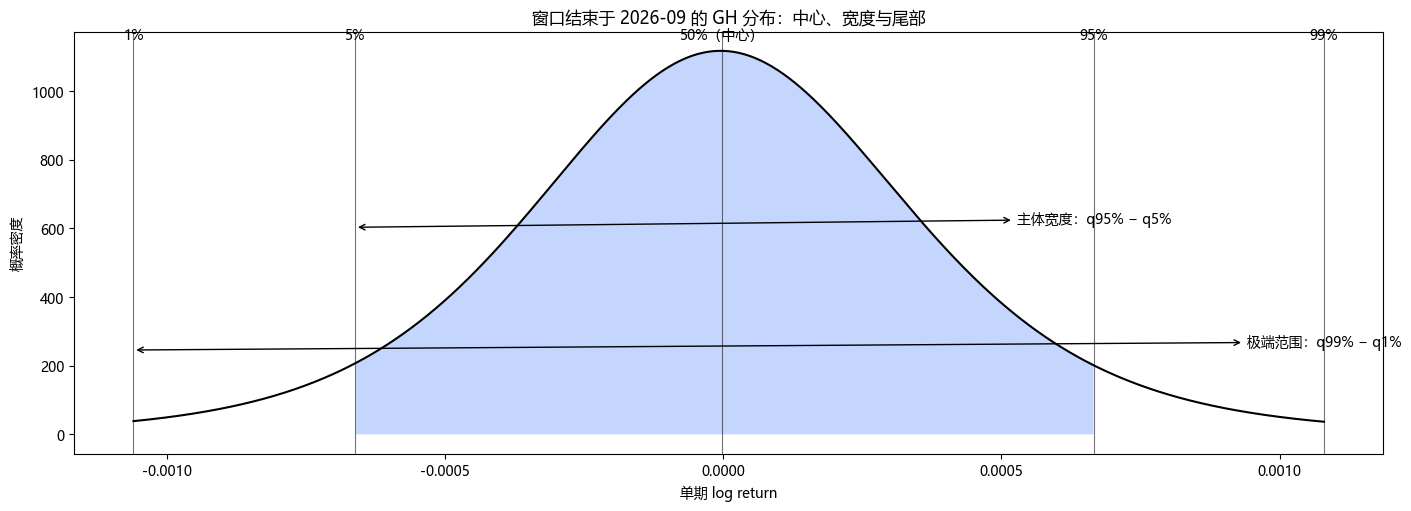

,结果列,图像要素
0,q50%,分布中心
1,std,分布宽度
2,skewness,左右不对称
3,excess_kurtosis,尾部厚度
4,q1%–q99%,整体极端范围


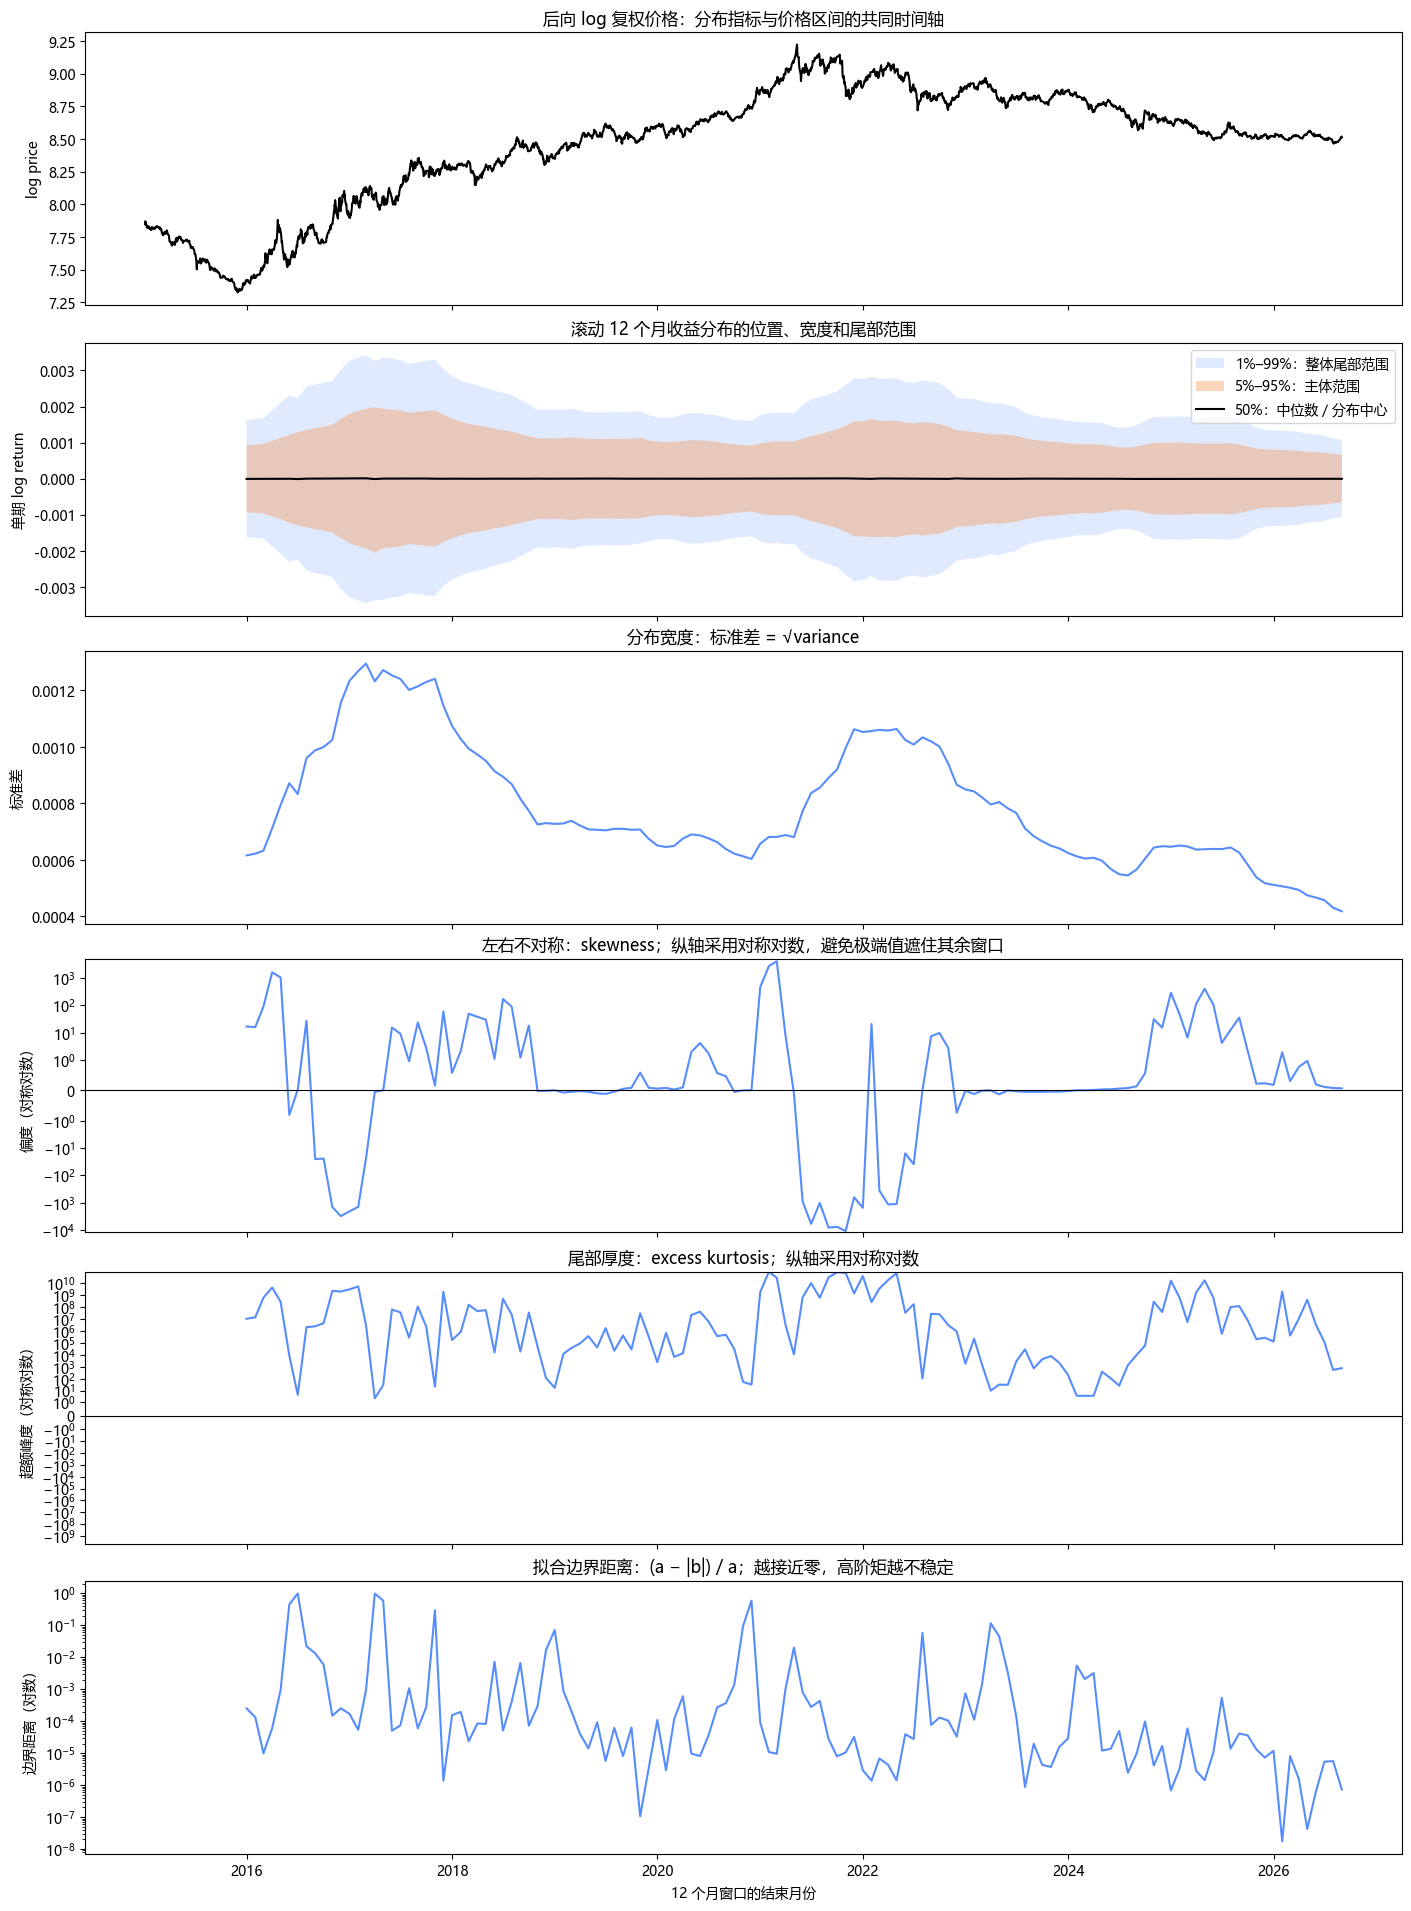

In [21]:
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

gh_plot_df = gh_distribution_df.copy()
gh_plot_df["window_end"] = pd.to_datetime(gh_plot_df["window_end"])
gh_plot_df["std"] = np.sqrt(gh_plot_df["variance"])
gh_plot_df["boundary_margin"] = (gh_plot_df["a"] - gh_plot_df["b"].abs()) / gh_plot_df["a"]

daily_log_price_df = (
    main_minute_df.sort_values("bar_at")
    .groupby("trading_date", as_index=False)["backward_adjusted_log_close"]
    .last()
)
daily_log_price_df["trading_date"] = pd.to_datetime(daily_log_price_df["trading_date"])

selected_window = gh_plot_df.iloc[-1]
x = np.linspace(selected_window["q1%"], selected_window["q99%"], 600)
density = genhyperbolic.pdf(
    x, selected_window["p"], selected_window["a"], selected_window["b"],
    loc=selected_window["loc"], scale=selected_window["scale"],
)

fig, ax = plt.subplots(figsize=(14, 5), layout="constrained")
ax.plot(x, density, color="black")
ax.fill_between(x, density, where=(x >= selected_window["q5%"]) & (x <= selected_window["q95%"]), alpha=0.35)

for quantile, label in [("q1%", "1%"), ("q5%", "5%"), ("q50%", "50%（中心）"), ("q95%", "95%"), ("q99%", "99%")]:
    ax.axvline(selected_window[quantile], color="black", linewidth=0.8, alpha=0.55)
    ax.text(selected_window[quantile], density.max() * 1.02, label, ha="center", va="bottom")

ax.annotate(
    "主体宽度：q95% − q5%",
    xy=(selected_window["q5%"], density.max() * 0.54),
    xytext=(selected_window["q95%"], density.max() * 0.54),
    arrowprops={"arrowstyle": "<->"}, ha="center", va="bottom",
)
ax.annotate(
    "极端范围：q99% − q1%",
    xy=(selected_window["q1%"], density.max() * 0.22),
    xytext=(selected_window["q99%"], density.max() * 0.22),
    arrowprops={"arrowstyle": "<->"}, ha="center", va="bottom",
)
ax.set_title(f"窗口结束于 {selected_window['window_end']:%Y-%m} 的 GH 分布：中心、宽度与尾部")
ax.set_xlabel("单期 log return")
ax.set_ylabel("概率密度")
plt.show()

fig, axes = plt.subplots(6, 1, figsize=(14, 19), sharex=True, layout="constrained")

axes[0].plot(daily_log_price_df["trading_date"], daily_log_price_df["backward_adjusted_log_close"], color="black")
axes[0].set_title("后向 log 复权价格：分布指标与价格区间的共同时间轴")
axes[0].set_ylabel("log price")


axes[1].fill_between(gh_plot_df["window_end"], gh_plot_df["q1%"], gh_plot_df["q99%"], alpha=0.18, label="1%–99%：整体尾部范围")
axes[1].fill_between(gh_plot_df["window_end"], gh_plot_df["q5%"], gh_plot_df["q95%"], alpha=0.35, label="5%–95%：主体范围")
axes[1].plot(gh_plot_df["window_end"], gh_plot_df["q50%"], color="black", label="50%：中位数／分布中心")
axes[1].set_title("滚动 12 个月收益分布的位置、宽度和尾部范围")
axes[1].set_ylabel("单期 log return")
axes[1].legend(loc="upper right")

axes[2].plot(gh_plot_df["window_end"], gh_plot_df["std"])
axes[2].set_title("分布宽度：标准差 = √variance")
axes[2].set_ylabel("标准差")

axes[3].plot(gh_plot_df["window_end"], gh_plot_df["skewness"])
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_yscale("symlog", linthresh=1)
axes[3].set_title("左右不对称：skewness；纵轴采用对称对数，避免极端值遮住其余窗口")
axes[3].set_ylabel("偏度（对称对数）")

axes[4].plot(gh_plot_df["window_end"], gh_plot_df["excess_kurtosis"])
axes[4].axhline(0, color="black", linewidth=0.8)
axes[4].set_yscale("symlog", linthresh=1)
axes[4].set_title("尾部厚度：excess kurtosis；纵轴采用对称对数")
axes[4].set_ylabel("超额峰度（对称对数）")

axes[5].plot(gh_plot_df["window_end"], gh_plot_df["boundary_margin"])
axes[5].set_yscale("log")
axes[5].set_title("拟合边界距离：(a − |b|) / a；越接近零，高阶矩越不稳定")
axes[5].set_ylabel("边界距离（对数）")
axes[5].set_xlabel("12 个月窗口的结束月份")

gh_feature_guide_df = pd.DataFrame({
    "结果列": ["q50%", "std", "skewness", "excess_kurtosis", "q1%–q99%"],
    "图像要素": ["分布中心", "分布宽度", "左右不对称", "尾部厚度", "整体极端范围"],
})

display(gh_feature_guide_df)
plt.show()